In [34]:
import matplotlib.pyplot as plt
import numpy as np
import math

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

import matplotlib.style #Some style nonsense
import matplotlib as mpl #Some more style nonsense

from scipy import linalg

#Set default figure size
#mpl.rcParams['figure.figsize'] = [12.0, 8.0] #Inches... of course it is inches
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']=200 # dots per inch

#Useful for debugging problems
print(tf.__version__)

2.18.0


In [35]:
mnist = keras.datasets.mnist   #The original handwritten digit MNIST
#mnist = keras.datasets.fashion_mnist   #A tricky version that uses images of fashion items
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Scale pixel value to between 0 and 1 before training them, otherwise model fit does not work
train_images=train_images/255.0
test_images=test_images/255.0



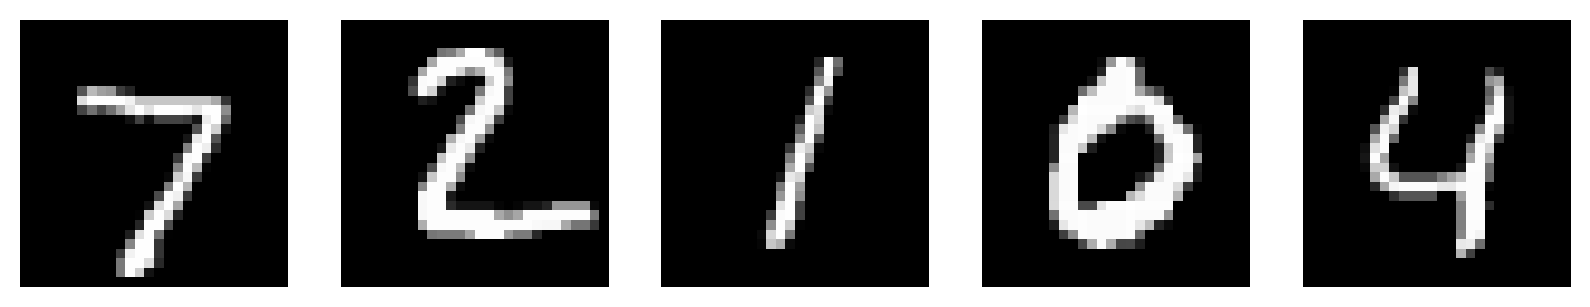

In [36]:

# Assuming 'test_images' is a collection of images for testing
# and 'num_images' specifies how many images to display

num_images = 5  # Adjust this value to change the number of displayed images

fig, axes = plt.subplots(1, num_images, figsize=(10, 5))  # Modify figsize to change plot size

for i in range(num_images):
  axes[i].imshow(test_images[i], cmap='gray')  # Show the image in grayscale
  axes[i].axis('off')  # Hide axis labels and ticks for a cleaner view

plt.show()


Building neural network

In [37]:
model = keras.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(10)
])

In [38]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
              metrics=['accuracy'])

Train the model

In [39]:
model.fit(train_images, train_labels,batch_size=100, epochs=10) # After testing it seems that 10 epochs is enough

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8468 - loss: 0.5313
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9549 - loss: 0.1602
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9669 - loss: 0.1123
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9732 - loss: 0.0914
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9778 - loss: 0.0750
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9822 - loss: 0.0585
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9855 - loss: 0.0482
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9876 - loss: 0.0416
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9882 - loss: 0.0375
Epoch 10/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9903 - loss: 0.0320


In [40]:
print(np.shape(test_images))

# Evaluate the model on the test dataset by comparing predictions with true labels.
# The 'verbose' parameter controls the amount of output displayed.
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print('\nTest accuracy:', test_acc)


(10000, 28, 28)
313/313 - 1s - 2ms/step - accuracy: 0.9736 - loss: 0.0979

Test accuracy: 0.9735999703407288


In [41]:
# Reshape the training images into a 2D array (60000 samples, 784 features)
X = np.reshape(train_images, (60000, 784))  # Each image (28x28) is flattened into a 784-dimensional vector
print("X.shape:", np.shape(X))  # Shape: (60000, 784)

# Compute the mean of the training data (to be used later)
mu = np.mean(X, axis=0)

# Compute the covariance matrix; the function automatically centers and normalizes the data
rho = np.cov(X, rowvar=False)
print("rho.shape:", np.shape(rho))  # Covariance matrix shape should be (784, 784)

# Compute the eigenvalues and eigenvectors of the covariance matrix
vals, vecs = linalg.eigh(rho)

# 'vals' contains eigenvalues in ascending order, 'vecs' contains eigenvectors as columns (vecs[:, i] corresponds to vals[i])
print("vecs.shape:", np.shape(vecs))
print("vals.shape:", np.shape(vals))

# Flip arrays to have principal components in descending order of variance
vecs = np.flip(vecs, axis=1)  # Eigenvectors corresponding to larger eigenvalues appear first
vals = np.flip(vals)          # Eigenvalues are also reordered in descending order

# Principal components represent the directions of maximum variance in the data.
# The first principal component corresponds to the largest eigenvalue.


X.shape: (60000, 784)
rho.shape: (784, 784)
vecs.shape: (784, 784)
vals.shape: (784,)


X.shape: (60000, 784)
P.shape: (60000, 784)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0956 - loss: 10.5647
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0931 - loss: 14.3242
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0948 - loss: 16.1738
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0959 - loss: 16.4362
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0947 - loss: 16.5444
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0953 - loss: 16.6085
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0950 - loss: 16.6130


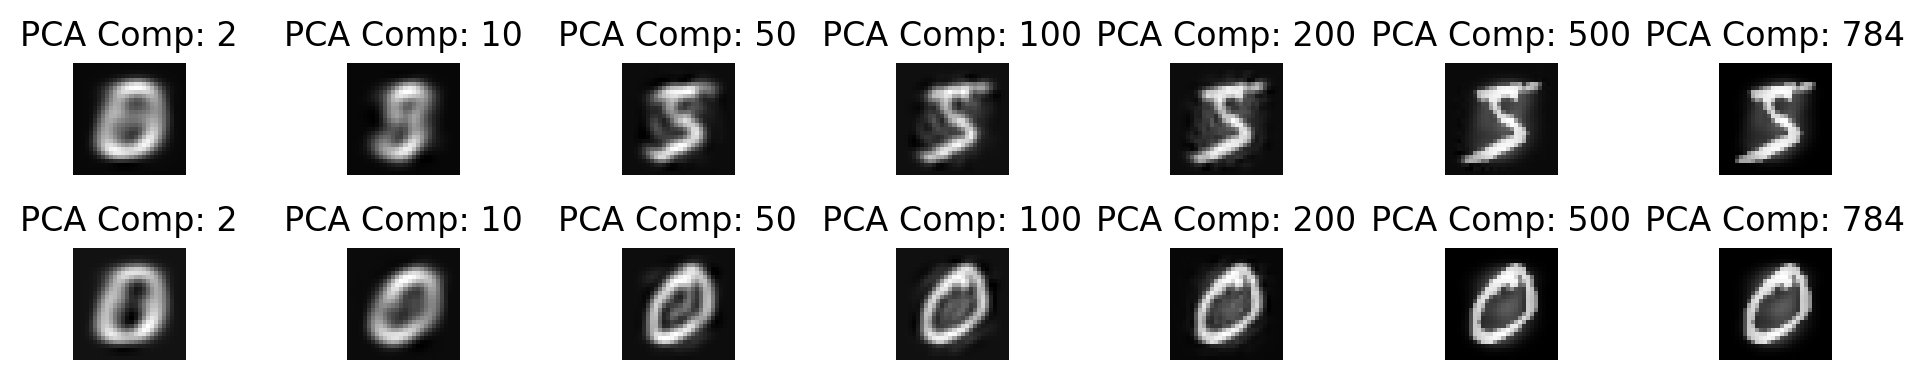

In [42]:
# Define the number of principal components to test and initialize an accuracy array
PCA_Components = np.array([2, 10, 50, 100, 200, 500, 784])  # Different PCA component counts to test
accuracy_array = np.zeros(len(PCA_Components))  # Initialize an array to store accuracy results

# Project the data into the principal component space
P = np.dot(X, vecs)  # Multiply the original data matrix X by the eigenvectors to get principal component projections

print("X.shape:", X.shape)  # Print the shape of the original dataset (60000, 784)
print("P.shape:", P.shape)  # Print the shape of the projected data (60000, 784)

# Number of images to display per PCA component
numbers = 2  # We will display 2 sample images per PCA component

# Create a subplot to visualize the reconstructed images
fig, axes = plt.subplots(numbers, len(PCA_Components), figsize=(10, 2))
# Create a grid of subplots with 'numbers' rows and as many columns as there are PCA components
# The figsize argument determines the overall size of the figure

# Evaluate model performance for different PCA component counts
for i in range(len(PCA_Components)):
    # Reconstruct images using the first PCA_Components[i] principal components
    # This is done by projecting the data into the reduced PCA space and then transforming it back
    newImages = np.dot(P[:, :PCA_Components[i]], vecs.T[:PCA_Components[i], :]) + mu
    # Multiply the top PCA components by their corresponding eigenvectors, then add the mean to reconstruct the images

    newImages = np.reshape(newImages[:10000], [10000, 28, 28])
    # Reshape the first 10,000 samples back into the original 28x28 image format

    # Evaluate the model performance on the reconstructed images
    predictions = model.evaluate(newImages, test_labels)  # Evaluate the trained model on these reconstructed images
    accuracy_array[i] = predictions[1]  # Store the accuracy score in the corresponding index of the array

    # Display the reconstructed images
    for j in range(numbers):
        axes[j, i].imshow(newImages[j], cmap='gray')  # Display the j-th reconstructed image for the i-th PCA component
        axes[j, i].axis('off')
        axes[j, i].set_title(f'PCA Comp: {PCA_Components[i]}')
plt.tight_layout()  # Adjust subplot spacing to minimize overlapping text and images
plt.show()  # Render the plot on the screen


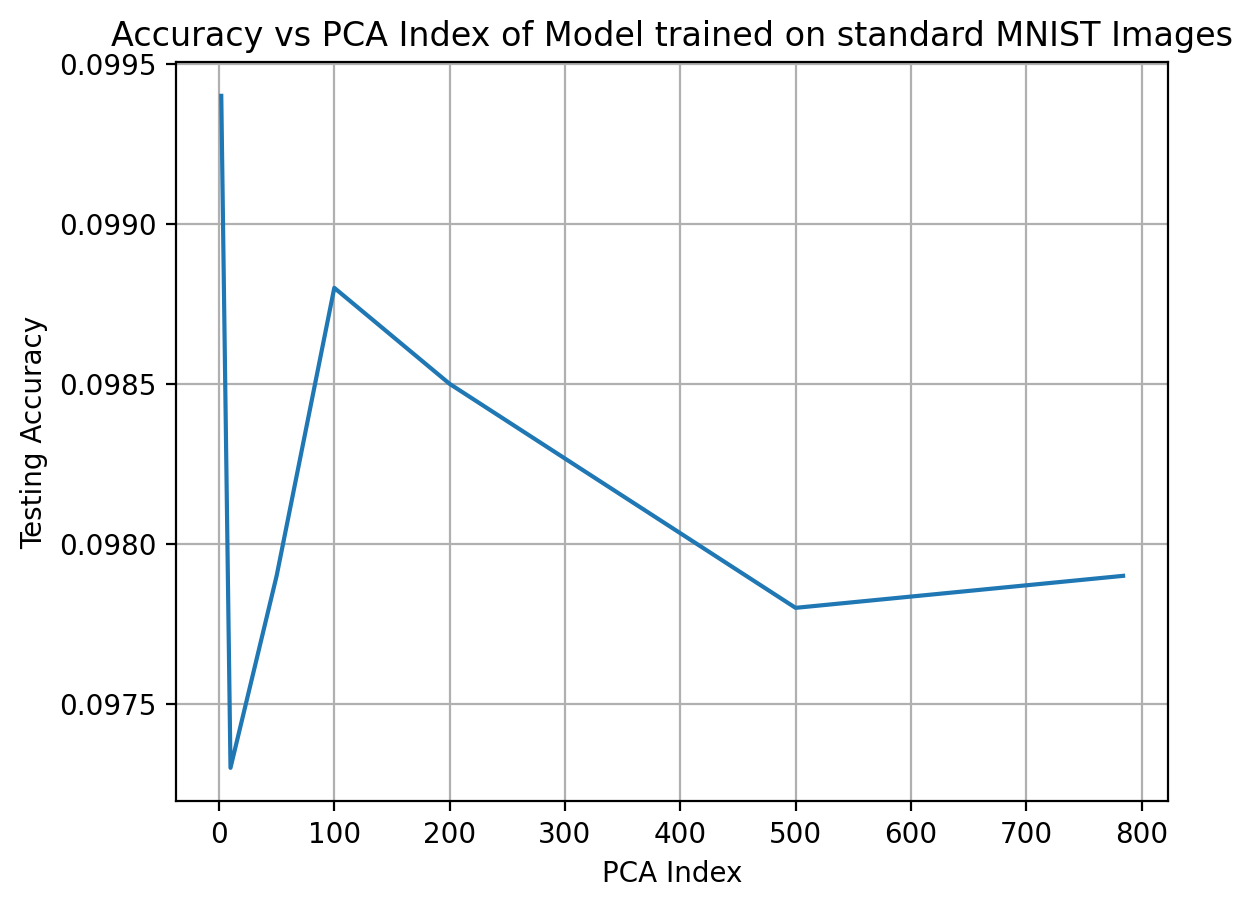

In [43]:
fig,ax=plt.subplots()
ax.plot(PCA_Components,accuracy_array)
ax.set_xlabel("PCA Index")
ax.set_ylabel("Testing Accuracy")
ax.set_title("Accuracy vs PCA Index of Model trained on standard MNIST Images")
ax.grid()

The model's accuracies consistently hover around 0.1, which aligns with the expected accuracy of a model making random guesses for the digit classification. This indicates that introducing noise to the images completely disrupts the performance of the model, which was exclusively trained on noise-free data.

Testing Trained model

In [44]:
# Reconstruct images using the first 100 principal components
newImages100 = np.dot(P[:, :100], vecs.T[:100, :]) + mu
newImages100 = np.reshape(newImages100, (60000, 28, 28))

# Train the model on the reconstructed images
model.fit(newImages100, train_labels, batch_size=100, epochs=7)  # 7 epochs are sufficient for convergence


Epoch 1/7
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9571 - loss: 0.1407
Epoch 2/7
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9756 - loss: 0.0748
Epoch 3/7
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9798 - loss: 0.0626
Epoch 4/7
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9823 - loss: 0.0556
Epoch 5/7
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9820 - loss: 0.0558
Epoch 6/7
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9831 - loss: 0.0521
Epoch 7/7
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9843 - loss: 0.0492


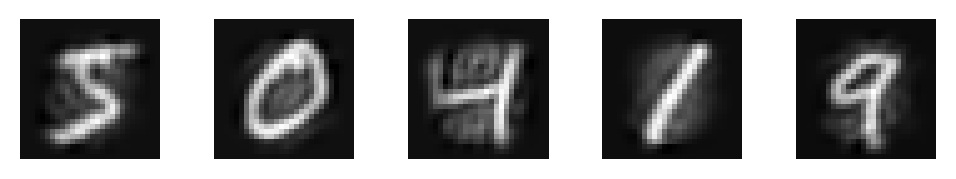

In [45]:
# Visualize a sample of the reconstructed images
NO_Images = 5
fig, axes = plt.subplots(1, NO_Images, figsize=(5, 1))

for i in range(NO_Images):
    axes[i].imshow(newImages100[i], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [46]:
# Evaluate the model's performance on the original test images
test_loss, test_acc = model.evaluate(train_images, train_labels, verbose=2)

# Print the test accuracy
print('\nTest accuracy:', test_acc)


1875/1875 - 4s - 2ms/step - accuracy: 0.9669 - loss: 0.1016

Test accuracy: 0.966949999332428


In [47]:
# Evaluate the model's performance on images reconstructed with different numbers of PCA components
for i in range(len(PCA_Components)):
    # Step 1: Reconstruct images using the first PCA_Components[i] principal components
    newImages100 = np.dot(P[:, :PCA_Components[i]], vecs.T[:PCA_Components[i], :]) + mu
    # Multiply the projected data (P) by the corresponding eigenvectors (vecs) to reconstruct the images.
    # Only the first PCA_Components[i] components are used. The mean (mu) is added to shift the data back.

    newImages100 = np.reshape(newImages100, (60000, 28, 28))
    # Reshape the reconstructed data from (60000, 784) back to the original image shape (60000, 28, 28).

    # Step 2: Evaluate model performance on the reconstructed images
    predictions = model.evaluate(newImages100, train_labels)
    # Evaluate the model's performance by comparing predictions with the true training labels.

    # Step 3: Record the accuracy for the current PCA component count
    accuracy_array[i] = predictions[1]  # Save the accuracy score (index 1 of predictions) to the array.



1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2353 - loss: 5.6610
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7835 - loss: 0.7956
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9742 - loss: 0.0849
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9852 - loss: 0.0454
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9867 - loss: 0.0408
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9897 - loss: 0.0348
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9899 - loss: 0.0344


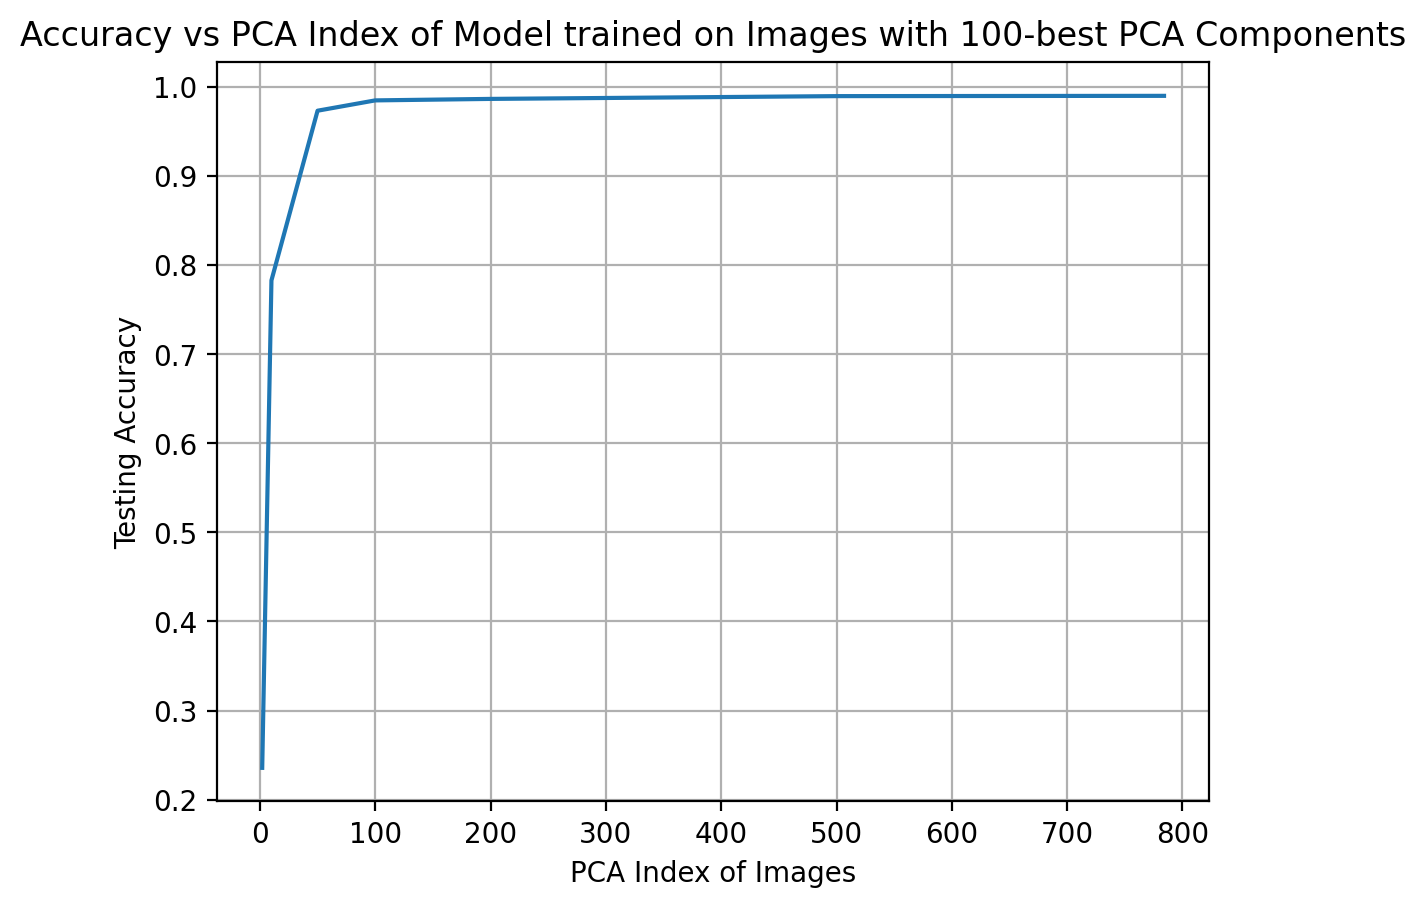

In [48]:
fig,ax=plt.subplots()
ax.plot(PCA_Components,accuracy_array)
ax.set_xlabel("PCA Index of Images")
ax.set_ylabel("Testing Accuracy")
ax.set_title("Accuracy vs PCA Index of Model trained on Images with 100-best PCA Components")
ax.grid()

The model's performance peaks at 100 PCA components, followed by a slight drop-off before stabilizing. This is unexpected, as one would typically assume that increasing the number of PCA components would enhance the model's ability to predict the images accurately.

20-best PCA component images.

In [49]:
# Reconstruct images using the first 20 principal components
newImages20 = np.dot(P[:, :20], vecs.T[:20, :]) + mu
newImages20 = np.reshape(newImages20, (60000, 28, 28))

# Train the model on the reconstructed images
model.fit(newImages20, train_labels, batch_size=100, epochs=25)


Epoch 1/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9429 - loss: 0.1880
Epoch 2/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9517 - loss: 0.1523
Epoch 3/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9564 - loss: 0.1387
Epoch 4/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9584 - loss: 0.1288
Epoch 5/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9588 - loss: 0.1291
Epoch 6/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9635 - loss: 0.1177
Epoch 7/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9601 - loss: 0.1233
Epoch 8/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9633 - loss: 0.1180
Epoch 9/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9632 - loss: 0.1186
Epoch 10/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9656 - loss: 0.1103
Epoch 11/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9657 - loss: 0.1114
Epoch 12/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

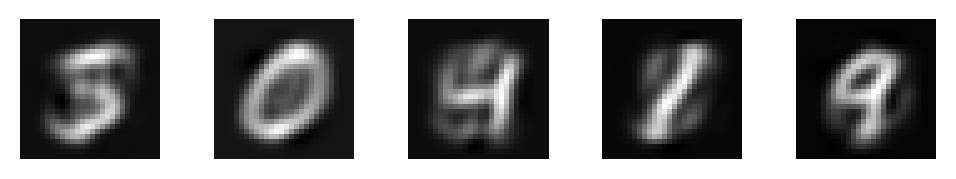

In [50]:
# Visualize a sample of the reconstructed images with 20 PCA components
NO_Images = 5
fig, axes = plt.subplots(1, NO_Images, figsize=(5, 1))

for i in range(NO_Images):
    axes[i].imshow(newImages20[i], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [51]:
# Lets check to see if the model still performs well on the test images
test_loss, test_acc = model.evaluate(train_images,  train_labels, verbose=2)
print('\nTest accuracy:', test_acc)

1875/1875 - 3s - 2ms/step - accuracy: 0.8878 - loss: 0.4794

Test accuracy: 0.8878166675567627


In [52]:
# Evaluate the model's performance on images reconstructed with different PCA component counts
for i in range(len(PCA_Components)):
    # Reconstruct images using the first PCA_Components[i] principal components
    newImages20 = np.dot(P[:, :PCA_Components[i]], vecs.T[:PCA_Components[i], :]) + mu
    newImages20 = np.reshape(newImages20, (60000, 28, 28))

    # Evaluate model performance on the reconstructed images
    predictions = model.evaluate(newImages20, train_labels)
    accuracy_array[i] = predictions[1]


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2219 - loss: 4.5494
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7768 - loss: 0.8493
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9626 - loss: 0.1218
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9602 - loss: 0.1297
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9545 - loss: 0.1561
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9539 - loss: 0.1604
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9538 - loss: 0.1619


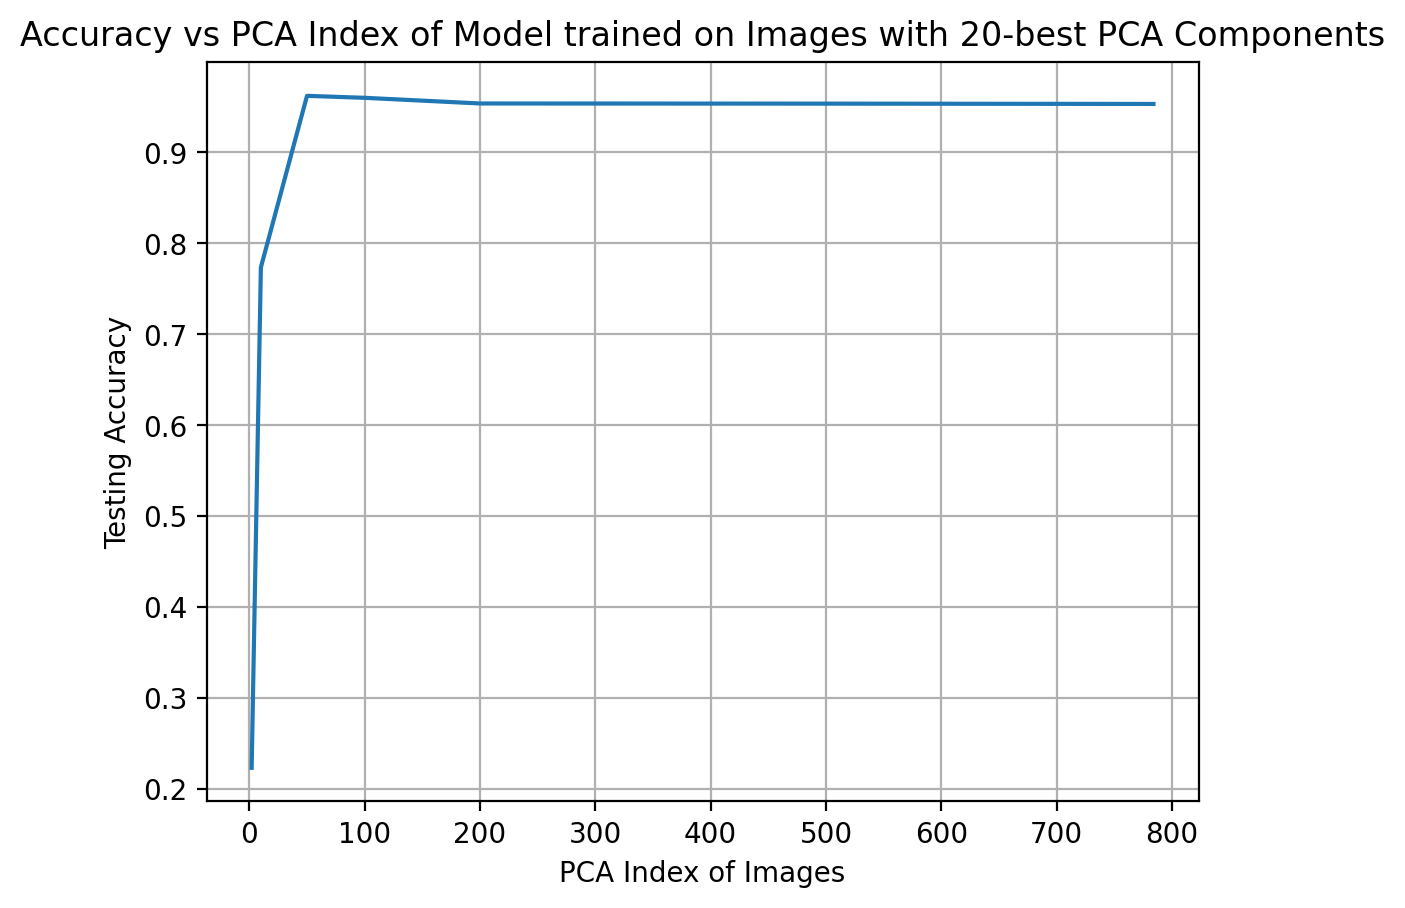

In [53]:
fig,ax=plt.subplots()
ax.plot(PCA_Components,accuracy_array)
ax.set_xlabel("PCA Index of Images")
ax.set_ylabel("Testing Accuracy")
ax.set_title("Accuracy vs PCA Index of Model trained on Images with 20-best PCA Components")
ax.grid()

The model's performance peaks around the 50-best PCA components before declining and stabilizing, mirroring the behavior observed in the model trained on the 100-best PCA components. The overall accuracy is lower, as expected, due to training on images with reduced detail.

When training a model, it is generally not advisable to use images with full detail, as done earlier, since the model should learn to recognize patterns even when some information is missing. However, using excessively simplified images, as seen with the 20-best PCA components, can make the learning process overly challenging. The optimal level of detail depends on the model's application, and users should train it on images representative of the tasks it will encounter during deployment.